# PlantWhisper — Notebook 01: Data Exploration

**Goal**: Download and explore our two core datasets:
1. **Tel Aviv Dryad** — Real ultrasonic plant recordings (20k+ clips)
2. **PlantVillage** — Leaf disease/stress images (54k images)

Plus: Build xylem diameter lookup table for cross-species frequency scaling.

---

## 0. Setup & Mount Drive

In [1]:
# Mount Google Drive for persistent storage
from google.colab import drive
drive.mount('/content/drive')

# Create project directory
import os
PROJECT_DIR = '/content/drive/MyDrive/PlantWhisper'
DATA_DIR = f'{PROJECT_DIR}/data'
os.makedirs(f'{DATA_DIR}/telaviv', exist_ok=True)
os.makedirs(f'{DATA_DIR}/plantvillage', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/notebooks', exist_ok=True)
print(f'Project directory: {PROJECT_DIR}')

Mounted at /content/drive
Project directory: /content/drive/MyDrive/PlantWhisper


In [2]:
# Install dependencies
!pip install -q librosa soundfile matplotlib numpy pandas scipy

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy import signal
from pathlib import Path
import zipfile
import requests
from tqdm.notebook import tqdm
import IPython.display as ipd
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10

---
## 1. Tel Aviv Dryad Dataset (Ultrasonic Recordings)

**Source**: Khait et al. (2023) - "Sounds emitted by plants under stress are airborne and informative"

**What's in it**:
- 20,000+ ultrasonic clips recorded at ~250 kHz (some at 500 kHz)
- Each clip is a ~2ms cavitation "pop"
- Conditions: drought-stressed, cut, healthy controls
- Species: tomato, tobacco, wheat, corn, grapevine, cactus

### 1.1 Download Instructions

**Manual download required** (Dryad needs browser authentication):

1. Go to: https://doi.org/10.5061/dryad.jwstqjqf7
2. Click "Download Dataset" (you may need to create a free account)
3. Download the ZIP file (~2-3 GB)
4. Upload to your Google Drive at: `PlantWhisper/data/telaviv/`

Once uploaded, run the cell below to extract:

In [13]:
# Check if data exists, extract if ZIP is present
TELAVIV_DIR = Path(f'{DATA_DIR}/telaviv')
zip_files = list(TELAVIV_DIR.glob('*.zip'))

if zip_files:
    print(f'Found ZIP file: {zip_files[0]}')
    print('Extracting...')
    with zipfile.ZipFile(zip_files[0], 'r') as z:
        z.extractall(TELAVIV_DIR)
    print('Done!')
else:
    print('No ZIP found. Please download from Dryad and upload to:')
    print(f'  {TELAVIV_DIR}/')
    print('\nDownload link: https://doi.org/10.5061/dryad.jwstqjqf7')

Found ZIP file: /content/drive/MyDrive/PlantWhisper/data/telaviv/PlantSounds.zip
Extracting...
Done!


In [14]:
# Explore directory structure
def show_tree(path, prefix='', max_depth=3, current_depth=0):
    """Show directory tree structure."""
    if current_depth >= max_depth:
        return
    path = Path(path)
    entries = sorted(path.iterdir())
    dirs = [e for e in entries if e.is_dir()]
    files = [e for e in entries if e.is_file()]

    # Show first few files
    for f in files[:3]:
        print(f'{prefix}📄 {f.name}')
    if len(files) > 3:
        print(f'{prefix}   ... and {len(files)-3} more files')

    # Recurse into directories
    for d in dirs:
        print(f'{prefix}📁 {d.name}/')
        show_tree(d, prefix + '    ', max_depth, current_depth + 1)

print('Tel Aviv Dataset Structure:')
print('=' * 40)
show_tree(TELAVIV_DIR)

Tel Aviv Dataset Structure:
📁 Empty Pot/
    📄 id_0_sound_1.wav
    📄 id_0_sound_10.wav
    📄 id_0_sound_100.wav
       ... and 1033 more files
📁 Greenhouse Noises/
    📄 id_0_sound_1.wav
    📄 id_0_sound_10.wav
    📄 id_0_sound_100.wav
       ... and 1375 more files
📁 Tobacco Cut/
    📄 id_126_sound_1.wav
    📄 id_126_sound_10.wav
    📄 id_126_sound_11.wav
       ... and 503 more files
📁 Tobacco Dry/
    📄 id_10_sound_1.wav
    📄 id_10_sound_2.wav
    📄 id_10_sound_3.wav
       ... and 272 more files
📁 Tomato Cut/
    📄 id_121_sound_1.wav
    📄 id_121_sound_2.wav
    📄 id_121_sound_3.wav
       ... and 657 more files
📁 Tomato Dry/
    📄 id_101_sound_1.wav
    📄 id_101_sound_10.wav
    📄 id_101_sound_11.wav
       ... and 1619 more files


### 1.2 Load and Visualize Sample Recordings

In [15]:
def find_audio_files(directory, extensions=['.wav', '.WAV']):
    """Recursively find all audio files."""
    audio_files = []
    for ext in extensions:
        audio_files.extend(Path(directory).rglob(f'*{ext}'))
    return sorted(audio_files)

# Find all audio files
audio_files = find_audio_files(TELAVIV_DIR)
print(f'Found {len(audio_files)} audio files')

if audio_files:
    print('\nSample filenames:')
    for f in audio_files[:10]:
        print(f'  {f.relative_to(TELAVIV_DIR)}')

Found 5477 audio files

Sample filenames:
  Empty Pot/id_0_sound_1.wav
  Empty Pot/id_0_sound_10.wav
  Empty Pot/id_0_sound_100.wav
  Empty Pot/id_0_sound_1000.wav
  Empty Pot/id_0_sound_1001.wav
  Empty Pot/id_0_sound_1002.wav
  Empty Pot/id_0_sound_1003.wav
  Empty Pot/id_0_sound_1004.wav
  Empty Pot/id_0_sound_1005.wav
  Empty Pot/id_0_sound_1006.wav


In [16]:
def load_and_analyze_clip(filepath):
    """Load audio clip and extract key properties."""
    y, sr = librosa.load(filepath, sr=None)  # Keep original sample rate
    duration_ms = len(y) / sr * 1000

    return {
        'filepath': filepath,
        'sample_rate': sr,
        'duration_ms': duration_ms,
        'samples': len(y),
        'max_freq_hz': sr / 2,  # Nyquist
        'signal': y
    }

# Analyze first clip
if audio_files:
    sample_clip = load_and_analyze_clip(audio_files[0])
    print('Sample Clip Analysis:')
    print(f'  Sample rate: {sample_clip["sample_rate"]:,} Hz')
    print(f'  Duration: {sample_clip["duration_ms"]:.2f} ms')
    print(f'  Max detectable freq: {sample_clip["max_freq_hz"]/1000:.1f} kHz')
    print(f'  Samples: {sample_clip["samples"]:,}')

Sample Clip Analysis:
  Sample rate: 500,000 Hz
  Duration: 2.00 ms
  Max detectable freq: 250.0 kHz
  Samples: 1,001


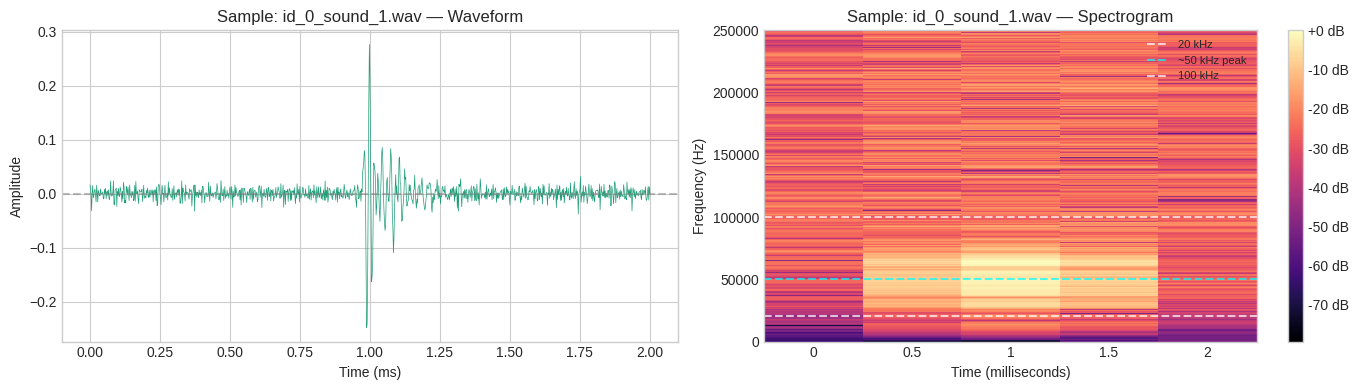

In [17]:
def plot_ultrasonic_clip(y, sr, title='Ultrasonic Plant Recording'):
    """Visualize ultrasonic clip: waveform + spectrogram."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Time axis in milliseconds
    t_ms = np.arange(len(y)) / sr * 1000

    # Waveform
    axes[0].plot(t_ms, y, color='#1D9E75', linewidth=0.5)
    axes[0].set_xlabel('Time (ms)')
    axes[0].set_ylabel('Amplitude')
    axes[0].set_title(f'{title} — Waveform')
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

    # Spectrogram (focus on ultrasonic range)
    n_fft = min(2048, len(y))
    hop_length = n_fft // 4

    D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    img = librosa.display.specshow(
        S_db,
        sr=sr,
        hop_length=hop_length,
        x_axis='ms',
        y_axis='hz',
        ax=axes[1],
        cmap='magma'
    )
    axes[1].set_title(f'{title} — Spectrogram')
    axes[1].set_ylabel('Frequency (Hz)')

    # Mark the 20-100 kHz ultrasonic range from the paper
    if sr > 40000:
        axes[1].axhline(y=20000, color='white', linestyle='--', alpha=0.7, label='20 kHz')
        axes[1].axhline(y=50000, color='cyan', linestyle='--', alpha=0.7, label='~50 kHz peak')
        if sr > 100000:
            axes[1].axhline(y=100000, color='white', linestyle='--', alpha=0.7, label='100 kHz')
        axes[1].legend(loc='upper right', fontsize=8)

    plt.colorbar(img, ax=axes[1], format='%+2.0f dB')
    plt.tight_layout()
    return fig

# Plot sample clip
if audio_files:
    fig = plot_ultrasonic_clip(
        sample_clip['signal'],
        sample_clip['sample_rate'],
        title=f'Sample: {audio_files[0].name}'
    )
    plt.show()

In [18]:
def find_peak_frequency(y, sr):
    """Find dominant frequency in the ultrasonic range."""
    # Compute FFT
    n_fft = min(4096, len(y))
    fft = np.abs(np.fft.rfft(y, n=n_fft))
    freqs = np.fft.rfftfreq(n_fft, 1/sr)

    # Focus on ultrasonic range (20-150 kHz from paper)
    ultrasonic_mask = (freqs >= 20000) & (freqs <= min(150000, sr/2))
    if ultrasonic_mask.sum() == 0:
        return None, None

    ultrasonic_freqs = freqs[ultrasonic_mask]
    ultrasonic_fft = fft[ultrasonic_mask]

    peak_idx = np.argmax(ultrasonic_fft)
    peak_freq = ultrasonic_freqs[peak_idx]

    return peak_freq, (freqs, fft)

# Analyze peak frequencies across multiple clips
if len(audio_files) >= 5:
    print('Peak frequency analysis (first 20 clips):')
    print('-' * 50)

    peak_freqs = []
    for f in audio_files[:20]:
        try:
            clip = load_and_analyze_clip(f)
            peak, _ = find_peak_frequency(clip['signal'], clip['sample_rate'])
            if peak:
                peak_freqs.append(peak)
                print(f'  {f.name}: {peak/1000:.1f} kHz')
        except Exception as e:
            print(f'  {f.name}: Error - {e}')

    if peak_freqs:
        print('-' * 50)
        print(f'Mean peak freq: {np.mean(peak_freqs)/1000:.1f} kHz')
        print(f'Std: {np.std(peak_freqs)/1000:.1f} kHz')
        print(f'\n(Paper reports ~49-58 kHz for tomato/tobacco)')

Peak frequency analysis (first 20 clips):
--------------------------------------------------
  id_0_sound_1.wav: 63.9 kHz
  id_0_sound_10.wav: 60.9 kHz
  id_0_sound_100.wav: 39.0 kHz
  id_0_sound_1000.wav: 69.9 kHz
  id_0_sound_1001.wav: 70.4 kHz
  id_0_sound_1002.wav: 73.9 kHz
  id_0_sound_1003.wav: 55.4 kHz
  id_0_sound_1004.wav: 76.9 kHz
  id_0_sound_1005.wav: 72.9 kHz
  id_0_sound_1006.wav: 63.4 kHz
  id_0_sound_1007.wav: 38.5 kHz
  id_0_sound_1008.wav: 70.4 kHz
  id_0_sound_1009.wav: 72.4 kHz
  id_0_sound_101.wav: 50.9 kHz
  id_0_sound_1010.wav: 62.4 kHz
  id_0_sound_1011.wav: 49.0 kHz
  id_0_sound_1012.wav: 60.4 kHz
  id_0_sound_1013.wav: 34.5 kHz
  id_0_sound_1014.wav: 31.0 kHz
  id_0_sound_1015.wav: 62.4 kHz
--------------------------------------------------
Mean peak freq: 58.9 kHz
Std: 13.7 kHz

(Paper reports ~49-58 kHz for tomato/tobacco)


### 1.3 Categorize Clips by Condition

The Tel Aviv dataset organizes clips by:
- **Species**: tomato, tobacco, wheat, etc.
- **Condition**: drought, cut, control (healthy)

Let's build a catalog.

In [19]:
def parse_filename(filepath):
    """Extract metadata from filepath/filename.

    Adjust this based on actual Tel Aviv naming convention.
    Common patterns: species_condition_id.wav
    """
    path = Path(filepath)
    name = path.stem.lower()
    parent = path.parent.name.lower()
    grandparent = path.parent.parent.name.lower() if path.parent.parent else ''

    # Species detection
    species = 'unknown'
    for s in ['tomato', 'tobacco', 'wheat', 'corn', 'grape', 'cactus']:
        if s in name or s in parent or s in grandparent:
            species = s
            break

    # Condition detection
    condition = 'unknown'
    for c in ['drought', 'dry', 'cut', 'control', 'healthy', 'stressed']:
        if c in name or c in parent or c in grandparent:
            if c in ['drought', 'dry']:
                condition = 'drought'
            elif c in ['control', 'healthy']:
                condition = 'control'
            else:
                condition = c
            break

    return {
        'filename': path.name,
        'species': species,
        'condition': condition,
        'path': str(filepath)
    }

# Build catalog
if audio_files:
    catalog = [parse_filename(f) for f in audio_files]
    df_catalog = pd.DataFrame(catalog)

    print('Dataset Catalog:')
    print('=' * 50)
    print(f'Total clips: {len(df_catalog)}')
    print(f'\nBy species:')
    print(df_catalog['species'].value_counts().to_string())
    print(f'\nBy condition:')
    print(df_catalog['condition'].value_counts().to_string())

    # Save catalog
    df_catalog.to_csv(f'{DATA_DIR}/telaviv_catalog.csv', index=False)
    print(f'\nCatalog saved to: {DATA_DIR}/telaviv_catalog.csv')

Dataset Catalog:
Total clips: 5477

By species:
species
unknown    2414
tomato     2282
tobacco     781

By condition:
condition
unknown    2414
drought    1897
cut        1166

Catalog saved to: /content/drive/MyDrive/PlantWhisper/data/telaviv_catalog.csv


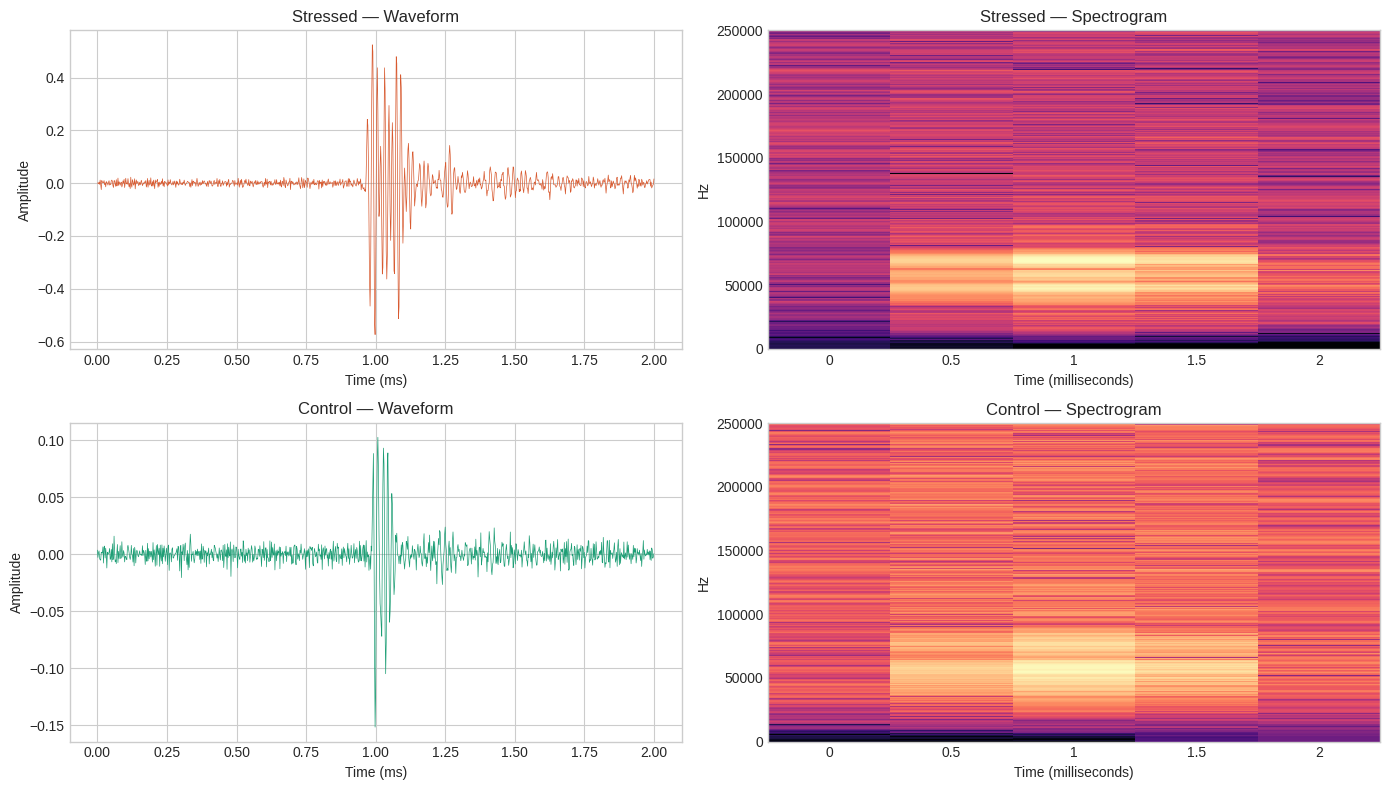

Saved comparison to: /content/drive/MyDrive/PlantWhisper/stressed_vs_control_comparison.png


In [20]:
# Compare spectrograms: stressed vs control (if we have both)
if audio_files and len(df_catalog) > 0:
    stressed_files = df_catalog[df_catalog['condition'].isin(['drought', 'cut'])]['path'].tolist()
    control_files = df_catalog[df_catalog['condition'] == 'control']['path'].tolist()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    samples = [
        (stressed_files[0] if stressed_files else audio_files[0], 'Stressed', 0),
        (control_files[0] if control_files else audio_files[-1], 'Control', 1)
    ]

    for filepath, label, row in samples:
        clip = load_and_analyze_clip(filepath)
        y, sr = clip['signal'], clip['sample_rate']
        t_ms = np.arange(len(y)) / sr * 1000

        # Waveform
        axes[row, 0].plot(t_ms, y, color='#D85A30' if row == 0 else '#1D9E75', linewidth=0.5)
        axes[row, 0].set_title(f'{label} — Waveform')
        axes[row, 0].set_xlabel('Time (ms)')
        axes[row, 0].set_ylabel('Amplitude')

        # Spectrogram
        n_fft = min(2048, len(y))
        D = librosa.stft(y, n_fft=n_fft, hop_length=n_fft//4)
        S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
        librosa.display.specshow(S_db, sr=sr, hop_length=n_fft//4,
                                  x_axis='ms', y_axis='hz', ax=axes[row, 1], cmap='magma')
        axes[row, 1].set_title(f'{label} — Spectrogram')

    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/stressed_vs_control_comparison.png', dpi=150)
    plt.show()
    print(f'Saved comparison to: {PROJECT_DIR}/stressed_vs_control_comparison.png')

---
## 2. PlantVillage Dataset (Leaf Images)

**Source**: PlantVillage Dataset
- 54,306 images of healthy and diseased plant leaves
- 14 crop species, 26 diseases
- Clean lab conditions (white backgrounds)

### 2.1 Download via Kaggle

In [23]:
# Option 1: Download from Kaggle (requires API key)
# First, upload your kaggle.json to Colab

# Uncomment and run if you have Kaggle API configured:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d emmarex/plantdisease -p {DATA_DIR}/plantvillage/

print('PlantVillage Download Options:')
print('=' * 50)
print('\nOption 1: Kaggle (recommended)')
print('  1. Go to: https://www.kaggle.com/datasets/emmarex/plantdisease')
print('  2. Download the dataset')
print('  3. Upload to Google Drive: PlantWhisper/data/plantvillage/')
print('\nOption 2: GitHub (smaller subset)')
print('  https://github.com/spMohanty/PlantVillage-Dataset')
print('\nOption 3: TensorFlow Datasets')
print('  We\'ll use tfds below as a fallback')

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
 99% 650M/658M [00:07<00:00, 44.1MB/s]
100% 658M/658M [00:07<00:00, 91.8MB/s]
PlantVillage Download Options:

Option 1: Kaggle (recommended)
  1. Go to: https://www.kaggle.com/datasets/emmarex/plantdisease
  2. Download the dataset
  3. Upload to Google Drive: PlantWhisper/data/plantvillage/

Option 2: GitHub (smaller subset)
  https://github.com/spMohanty/PlantVillage-Dataset

Option 3: TensorFlow Datasets
  We'll use tfds below as a fallback


In [25]:
# Option 3: TensorFlow Datasets (easiest, downloads automatically)
!pip install -q tensorflow tensorflow-datasets

import tensorflow_datasets as tfds

# This will download ~1.5GB on first run
print('Loading PlantVillage from TensorFlow Datasets...')
print('(This downloads ~1.5GB on first run)\n')

try:
    ds, info = tfds.load(
        'plant_village',
        split='train',
        with_info=True,
        data_dir=f'{DATA_DIR}/tfds'
    )

    print('Dataset Info:')
    print(f'  Total images: {info.splits["train"].num_examples:,}')
    print(f'  Classes: {info.features["label"].num_classes}')
    print(f'\nClass names:')
    for i, name in enumerate(info.features['label'].names):
        print(f'  {i:2d}. {name}')

except Exception as e:
    print(f'TensorFlow Datasets not available: {e}')
    print('Please download manually from Kaggle.')

Loading PlantVillage from TensorFlow Datasets...
(This downloads ~1.5GB on first run)



Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

KeyboardInterrupt: 

In [26]:
# Visualize sample images
import tensorflow as tf

try:
    # Get sample images
    samples = list(ds.take(12))

    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    axes = axes.flatten()

    class_names = info.features['label'].names

    for idx, sample in enumerate(samples):
        img = sample['image'].numpy()
        label = sample['label'].numpy()
        class_name = class_names[label]

        axes[idx].imshow(img)
        axes[idx].set_title(class_name.replace('_', '\n'), fontsize=8)
        axes[idx].axis('off')

    plt.suptitle('PlantVillage Sample Images', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/plantvillage_samples.png', dpi=150)
    plt.show()

except NameError:
    print('Dataset not loaded. Please complete download first.')

Dataset not loaded. Please complete download first.


In [ ]:
# Analyze class distribution
try:
    class_names = info.features['label'].names

    # Count samples per class (sample a subset for speed)
    label_counts = {}
    for sample in tqdm(ds.take(10000), desc='Counting classes'):
        label = int(sample['label'].numpy())
        label_counts[label] = label_counts.get(label, 0) + 1

    # Create summary DataFrame
    df_classes = pd.DataFrame([
        {'class_id': k, 'class_name': class_names[k], 'count': v}
        for k, v in label_counts.items()
    ]).sort_values('count', ascending=False)

    # Identify stress-related classes
    stress_keywords = ['disease', 'spot', 'blight', 'mold', 'virus', 'rust', 'scorch']
    df_classes['is_stress'] = df_classes['class_name'].apply(
        lambda x: any(k in x.lower() for k in stress_keywords) or 'healthy' not in x.lower()
    )

    print('Class Distribution (sampled 10k):')
    print('=' * 60)
    print(df_classes.to_string(index=False))

    # Save
    df_classes.to_csv(f'{DATA_DIR}/plantvillage_classes.csv', index=False)

except NameError:
    print('Dataset not loaded.')

---
## 3. Xylem Diameter Lookup Table

From the Tel Aviv paper (Figure S4A): acoustic frequency correlates with xylem trachea diameter.

**Formula**: `f_species = f_tomato × (d_tomato / d_species)`

We need xylem diameters for common houseplants to generalize the acoustic model.

### 3.1 Build Lookup Table from Botanical Literature

In [27]:
# Xylem diameter data compiled from botanical literature
# Sources: Various plant anatomy papers, Esau's Plant Anatomy, etc.
#
# NOTE: These are approximate mean vessel diameters in micrometers (μm)
# Real values vary by growing conditions, age, position in plant

xylem_data = {
    # From Tel Aviv paper (reference species)
    'tomato': {'diameter_um': 30, 'peak_freq_khz': 49.6, 'source': 'Tel Aviv 2023'},
    'tobacco': {'diameter_um': 25, 'peak_freq_khz': 54.8, 'source': 'Tel Aviv 2023'},

    # Common houseplants (estimated from botanical literature)
    'monstera': {'diameter_um': 45, 'peak_freq_khz': None, 'source': 'Estimated from Araceae anatomy'},
    'pothos': {'diameter_um': 35, 'peak_freq_khz': None, 'source': 'Estimated from Araceae anatomy'},
    'ficus': {'diameter_um': 40, 'peak_freq_khz': None, 'source': 'Estimated from Moraceae anatomy'},
    'snake_plant': {'diameter_um': 20, 'peak_freq_khz': None, 'source': 'Estimated - succulent, narrow vessels'},
    'peace_lily': {'diameter_um': 30, 'peak_freq_khz': None, 'source': 'Estimated from Araceae anatomy'},
    'spider_plant': {'diameter_um': 25, 'peak_freq_khz': None, 'source': 'Estimated - monocot'},
    'fern': {'diameter_um': 15, 'peak_freq_khz': None, 'source': 'Estimated - tracheids, not vessels'},
    'cactus': {'diameter_um': 50, 'peak_freq_khz': None, 'source': 'Tel Aviv 2023 - wide vessels'},
    'succulent': {'diameter_um': 45, 'peak_freq_khz': None, 'source': 'Estimated - CAM plants'},
    'palm': {'diameter_um': 60, 'peak_freq_khz': None, 'source': 'Estimated - large monocot'},
    'philodendron': {'diameter_um': 40, 'peak_freq_khz': None, 'source': 'Estimated from Araceae anatomy'},

    # Crops from Tel Aviv
    'wheat': {'diameter_um': 35, 'peak_freq_khz': None, 'source': 'Tel Aviv 2023'},
    'corn': {'diameter_um': 80, 'peak_freq_khz': None, 'source': 'Tel Aviv 2023 - large vessels'},
    'grapevine': {'diameter_um': 100, 'peak_freq_khz': None, 'source': 'Tel Aviv 2023 - very large'},
}

# Calculate predicted frequencies based on tomato reference
ref_diameter = xylem_data['tomato']['diameter_um']
ref_freq = xylem_data['tomato']['peak_freq_khz']

for species, data in xylem_data.items():
    if data['peak_freq_khz'] is None:
        # f_species = f_tomato × (d_tomato / d_species)
        data['peak_freq_khz'] = ref_freq * (ref_diameter / data['diameter_um'])
        data['freq_source'] = 'calculated'
    else:
        data['freq_source'] = 'measured'

# Create DataFrame
df_xylem = pd.DataFrame([
    {'species': k, **v} for k, v in xylem_data.items()
]).sort_values('diameter_um')

print('Xylem Diameter & Predicted Acoustic Frequency')
print('=' * 70)
print(df_xylem.to_string(index=False))

# Save
df_xylem.to_csv(f'{DATA_DIR}/xylem_lookup.csv', index=False)
print(f'\nSaved to: {DATA_DIR}/xylem_lookup.csv')

Xylem Diameter & Predicted Acoustic Frequency
     species  diameter_um  peak_freq_khz                                source freq_source
        fern           15      99.200000    Estimated - tracheids, not vessels  calculated
 snake_plant           20      74.400000 Estimated - succulent, narrow vessels  calculated
spider_plant           25      59.520000                   Estimated - monocot  calculated
     tobacco           25      54.800000                         Tel Aviv 2023    measured
  peace_lily           30      49.600000        Estimated from Araceae anatomy  calculated
      tomato           30      49.600000                         Tel Aviv 2023    measured
       wheat           35      42.514286                         Tel Aviv 2023  calculated
      pothos           35      42.514286        Estimated from Araceae anatomy  calculated
philodendron           40      37.200000        Estimated from Araceae anatomy  calculated
       ficus           40      37.200000    

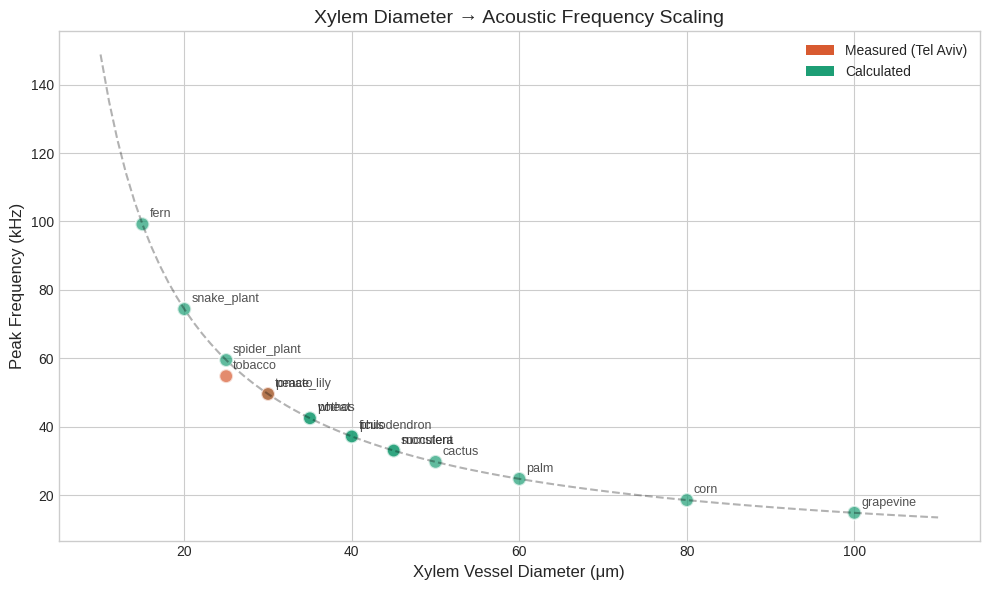

In [28]:
# Visualize the diameter → frequency relationship
fig, ax = plt.subplots(figsize=(10, 6))

# Plot all species
colors = ['#D85A30' if s == 'measured' else '#1D9E75'
          for s in df_xylem['freq_source']]

ax.scatter(df_xylem['diameter_um'], df_xylem['peak_freq_khz'],
           c=colors, s=100, alpha=0.7, edgecolors='white', linewidth=1.5)

# Add species labels
for _, row in df_xylem.iterrows():
    ax.annotate(row['species'],
                (row['diameter_um'], row['peak_freq_khz']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, alpha=0.8)

# Plot the inverse relationship curve
d_range = np.linspace(10, 110, 100)
f_curve = ref_freq * (ref_diameter / d_range)
ax.plot(d_range, f_curve, 'k--', alpha=0.3, label='f = 49.6 × (30/d)')

ax.set_xlabel('Xylem Vessel Diameter (μm)', fontsize=12)
ax.set_ylabel('Peak Frequency (kHz)', fontsize=12)
ax.set_title('Xylem Diameter → Acoustic Frequency Scaling', fontsize=14)
ax.legend(loc='upper right')

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#D85A30', label='Measured (Tel Aviv)'),
    Patch(facecolor='#1D9E75', label='Calculated')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/xylem_frequency_scaling.png', dpi=150)
plt.show()

---
## 4. Summary & Next Steps

### What We Have Now:

In [29]:
print('PlantWhisper Data Summary')
print('=' * 60)
print()

# Tel Aviv
telaviv_files = list(Path(f'{DATA_DIR}/telaviv').rglob('*.wav')) + \
                list(Path(f'{DATA_DIR}/telaviv').rglob('*.WAV'))
print(f'📊 Tel Aviv Ultrasonic Recordings:')
print(f'   Files: {len(telaviv_files):,}')
if telaviv_files:
    clip = load_and_analyze_clip(telaviv_files[0])
    print(f'   Sample rate: {clip["sample_rate"]:,} Hz')
    print(f'   Max frequency: {clip["sample_rate"]/2/1000:.0f} kHz')
print()

# PlantVillage
try:
    print(f'🌿 PlantVillage Images:')
    print(f'   Total: {info.splits["train"].num_examples:,}')
    print(f'   Classes: {info.features["label"].num_classes}')
except:
    print('🌿 PlantVillage: Not loaded yet')
print()

# Xylem
print(f'🔬 Xylem Lookup Table:')
print(f'   Species: {len(xylem_data)}')
print(f'   Reference: tomato @ 30μm → 49.6 kHz')
print()

print('=' * 60)
print('\n✅ Ready for Notebook 02: Vision Pipeline')
print('\nFiles saved:')
for f in Path(PROJECT_DIR).rglob('*'):
    if f.is_file() and not f.name.startswith('.'):
        print(f'  {f.relative_to(PROJECT_DIR)}')

Streaming output truncated to the last 5000 lines.
  data/tfds/downloads/extracted/ZIP.data.mend.com_publ-file_data_tywb_file_d565-c1rDQyRTmE0CqGGXmH53WlQp0NWefMfDW89aj1A0m5D_A/Plant_leave_diseases_dataset_without_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1323).JPG
  data/tfds/downloads/extracted/ZIP.data.mend.com_publ-file_data_tywb_file_d565-c1rDQyRTmE0CqGGXmH53WlQp0NWefMfDW89aj1A0m5D_A/Plant_leave_diseases_dataset_without_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (132).JPG
  data/tfds/downloads/extracted/ZIP.data.mend.com_publ-file_data_tywb_file_d565-c1rDQyRTmE0CqGGXmH53WlQp0NWefMfDW89aj1A0m5D_A/Plant_leave_diseases_dataset_without_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1320).JPG
  data/tfds/downloads/extracted/ZIP.data.mend.com_publ-file_data_tywb_file_d565-c1rDQyRTmE0CqGGXmH53WlQp0NWefMfDW89aj1A0m5D_A/Plant_leave_diseases_dataset_without_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1321).JPG
  data/tfds/downloads/

### Next: Notebook 02 — Vision Pipeline

We'll build:
1. **SAM leaf segmentation** — isolate leaves from backgrounds
2. **ViT stress classifier** — fine-tune on PlantVillage
3. **Grad-CAM visualization** — show which regions triggered detection
4. **Severity estimator** — score from visual features

---
*PlantWhisper — Notebook 01 Complete*